<a href="https://colab.research.google.com/github/anniemaerlin/Python/blob/main/D_10_NETFLIX_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ['KAGGLE_USERNAME'] ='Jeon AM'
os.environ['KAGGLE_KEY'] = 'KGAT_5a41921394e21bdd144bd830b43761a4'

In [ ]:
! kaggle datasets download -d 'gaddalaanjani/netfilx-dataset'

Dataset URL: https://www.kaggle.com/datasets/gaddalaanjani/netfilx-dataset
License(s): MIT
100% 2.73M/2.73M [00:00<00:00, 59.0MB/s]



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('netfilx-dataset.zip')
df

,Unnamed: 0,title,year,kind,genre,rating,vote,country,language,cast,director,composer,writer,runtime
0,0,Dinosaur Planet,2003.0,tv mini series,"['Documentary', 'Animation', 'Family']",7.7,474.0,['United States'],['English'],"['Christian Slater', 'Scott Sampson']",NaN,NaN,"['Mike Carrol', 'Mike Carroll', 'Georgann Kane']",50.0
1,1,Character,2021.0,movie,"['Crime', 'Horror', 'Thriller']",8.3,46.0,['Japan'],['Japanese'],"['Masaki Suda', 'Fukase', 'Mitsuki Takahata', ...",['Akira Nagai'],['Youki Kojima'],"['Takashi Nagasaki', 'Takashi Nagasaki', 'Anna...",125.0
2,2,Get Up and Dance!,1994.0,video movie,['Family'],8.1,18.0,['United States'],['English'],"['Paula Abdul', 'Aurorah Allain', 'Bill Bohl',...",['Steve Purcell'],NaN,NaN,54.0
3,3,The Rise and Fall of El Chapo,2016.0,tv movie,['Documentary'],6.9,42.0,['United States'],NaN,NaN,NaN,NaN,NaN,85.0
4,4,Sick - IMDb,NaN,NaN,['Thriller'],NaN,NaN,['United States'],NaN,"['Marc Menchaca', 'Gideon Adlon', 'Dylan Spray...",['John Hyams'],NaN,"['Katelyn Crabb', 'Kevin Williamson']",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9821,9821,All Monsters Attack,1969.0,movie,"['Adventure', 'Family', 'Fantasy']",3.9,4384.0,['Japan'],['Japanese'],"['Tomonori Yazaki', 'Hideyo Amamoto', 'Sachio ...","['Ishirô Honda', 'Jun Fukuda', 'Kengo Furusawa']",['Kunio Miyauchi'],"[""Shin'ichi Sekizawa""]",69.0
9822,9822,Fidel Castro,2005.0,episode,"['Documentary', 'Biography', 'History']",6.4,44.0,NaN,"['English', 'Spanish']","['Rena Baskin', 'Fulgencio Batista', 'James Bl...","['Adriana Bosch', 'M Pink Christofalo']",['Mason Daring'],['Adriana Bosch'],NaN
9823,9823,Epoch,2001.0,tv movie,"['Sci-Fi', 'Thriller']",4.9,2376.0,['United States'],['English'],"['David Keith', 'Stephanie Niznik', ""Ryan O'Ne...",['Matt Codd'],['Richard McHugh'],"['Jonathan Raymond', 'Jonathan Raymond', 'Phil...",96.0
9824,9824,The Company,2003.0,movie,"['Drama', 'Music', 'Romance']",6.3,6501.0,"['United States', 'Germany', 'United Kingdom']",['English'],"['Neve Campbell', 'Malcolm McDowell', 'James F...",['Robert Altman'],['Van Dyke Parks'],"['Neve Campbell', 'Barbara Turner', 'Barbara T...",112.0


In [ ]:
df.head()

,Unnamed: 0,title,year,kind,genre,rating,vote,country,language,cast,director,composer,writer,runtime
0,0,Dinosaur Planet,2003.0,tv mini series,"['Documentary', 'Animation', 'Family']",7.7,474.0,['United States'],['English'],"['Christian Slater', 'Scott Sampson']",NaN,NaN,"['Mike Carrol', 'Mike Carroll', 'Georgann Kane']",50.0
1,1,Character,2021.0,movie,"['Crime', 'Horror', 'Thriller']",8.3,46.0,['Japan'],['Japanese'],"['Masaki Suda', 'Fukase', 'Mitsuki Takahata', ...",['Akira Nagai'],['Youki Kojima'],"['Takashi Nagasaki', 'Takashi Nagasaki', 'Anna...",125.0
2,2,Get Up and Dance!,1994.0,video movie,['Family'],8.1,18.0,['United States'],['English'],"['Paula Abdul', 'Aurorah Allain', 'Bill Bohl',...",['Steve Purcell'],NaN,NaN,54.0
3,3,The Rise and Fall of El Chapo,2016.0,tv movie,['Documentary'],6.9,42.0,['United States'],NaN,NaN,NaN,NaN,NaN,85.0
4,4,Sick - IMDb,NaN,NaN,['Thriller'],NaN,NaN,['United States'],NaN,"['Marc Menchaca', 'Gideon Adlon', 'Dylan Spray...",['John Hyams'],NaN,"['Katelyn Crabb', 'Kevin Williamson']",NaN


In [ ]:
df.tail()

,Unnamed: 0,title,year,kind,genre,rating,vote,country,language,cast,director,composer,writer,runtime
9821,9821,All Monsters Attack,1969.0,movie,"['Adventure', 'Family', 'Fantasy']",3.9,4384.0,['Japan'],['Japanese'],"['Tomonori Yazaki', 'Hideyo Amamoto', 'Sachio ...","['Ishirô Honda', 'Jun Fukuda', 'Kengo Furusawa']",['Kunio Miyauchi'],"[""Shin'ichi Sekizawa""]",69.0
9822,9822,Fidel Castro,2005.0,episode,"['Documentary', 'Biography', 'History']",6.4,44.0,NaN,"['English', 'Spanish']","['Rena Baskin', 'Fulgencio Batista', 'James Bl...","['Adriana Bosch', 'M Pink Christofalo']",['Mason Daring'],['Adriana Bosch'],NaN
9823,9823,Epoch,2001.0,tv movie,"['Sci-Fi', 'Thriller']",4.9,2376.0,['United States'],['English'],"['David Keith', 'Stephanie Niznik', ""Ryan O'Ne...",['Matt Codd'],['Richard McHugh'],"['Jonathan Raymond', 'Jonathan Raymond', 'Phil...",96.0
9824,9824,The Company,2003.0,movie,"['Drama', 'Music', 'Romance']",6.3,6501.0,"['United States', 'Germany', 'United Kingdom']",['English'],"['Neve Campbell', 'Malcolm McDowell', 'James F...",['Robert Altman'],['Van Dyke Parks'],"['Neve Campbell', 'Barbara Turner', 'Barbara T...",112.0
9825,9825,Predator,1987.0,movie,"['Action', 'Adventure', 'Sci-Fi', 'Thriller']",7.8,386850.0,"['United States', 'Mexico']","['English', 'Spanish', 'Russian']","['Arnold Schwarzenegger', 'Carl Weathers', 'El...",['John McTiernan'],['Alan Silvestri'],"['Jim Thomas', 'John Thomas']",107.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9826 entries, 0 to 9825
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  9826 non-null   int64  
 1   title       9825 non-null   object 
 2   year        9756 non-null   float64
 3   kind        9788 non-null   object 
 4   genre       9733 non-null   object 
 5   rating      8949 non-null   float64
 6   vote        8949 non-null   float64
 7   country     9161 non-null   object 
 8   language    9033 non-null   object 
 9   cast        9482 non-null   object 
 10  director    7966 non-null   object 
 11  composer    6204 non-null   object 
 12  writer      8170 non-null   object 
 13  runtime     8770 non-null   float64
dtypes: float64(4), int64(1), object(9)
memory usage: 1.0+ MB


In [ ]:
df.shape

(9826, 14)

In [ ]:
df.columns

Index(['Unnamed: 0', 'title', 'year', 'kind', 'genre', 'rating', 'vote',
       'country', 'language', 'cast', 'director', 'composer', 'writer',
       'runtime'],
      dtype='object')

In [ ]:
df.describe()

,Unnamed: 0,year,rating,vote,runtime
count,9826.000000,9756.000000,8949.000000,8.949000e+03,8770.000000
mean,4912.500000,1994.739750,6.680635,2.121821e+04,98.069327
std,2836.666206,16.245087,1.285113,9.804873e+04,63.682914
min,0.000000,1905.000000,1.000000,5.000000e+00,1.000000
25%,2456.250000,1989.750000,6.000000,2.830000e+02,79.000000
50%,4912.500000,1999.000000,6.900000,1.535000e+03,94.000000
75%,7368.750000,2003.000000,7.600000,7.570000e+03,110.000000
max,9825.000000,2023.000000,9.600000,2.462087e+06,1620.000000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
title,1
year,70
kind,38
genre,93
rating,877
vote,877
country,665
language,793
cast,344


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.nunique()

,0
Unnamed: 0,9826
title,9214
year,109
kind,8
genre,1557
rating,84
vote,5036
country,728
language,768
cast,8850


In [ ]:
df['kind'].value_counts()

,count
kind,
movie,5541
video movie,1420
episode,893
tv series,813
tv movie,796
tv mini series,276
video game,34
tv short,15


In [ ]:
df['country'].value_counts().head(10)

,count
country,
['United States'],4322
['United Kingdom'],833
['Japan'],601
['India'],283
['Canada'],235
['Hong Kong'],216
['France'],173
"['United Kingdom', 'United States']",160
"['Canada', 'United States']",95


In [ ]:
df['language'].value_counts().head(10)

,count
language,
['English'],5710
['Japanese'],424
['Hindi'],214
['French'],190
"['English', 'Spanish']",133
"['English', 'French']",128
['Cantonese'],101
['Spanish'],89
"['Japanese', 'English']",86


In [ ]:
df['genre'].value_counts().head(10)

,count
genre,
['Drama'],517
['Documentary'],514
['Comedy'],405
"['Documentary', 'Music']",332
"['Drama', 'Romance']",309
['Music'],231
"['Comedy', 'Drama', 'Romance']",197
"['Comedy', 'Drama']",195
"['Comedy', 'Romance']",151


In [ ]:
df['rating'].mean()

np.float64(6.680634707788579)

In [ ]:
df['rating'].max()

9.6

In [ ]:
df['rating'].min()

1.0

In [ ]:
df.columns

Index(['Unnamed: 0', 'title', 'year', 'kind', 'genre', 'rating', 'vote',
       'country', 'language', 'cast', 'director', 'composer', 'writer',
       'runtime'],
      dtype='object')

In [ ]:
df.drop('composer', axis=1, inplace=True)

In [ ]:
df['content_age'] = 2026 - df['year']

In [ ]:
df.columns

Index(['Unnamed: 0', 'title', 'year', 'kind', 'genre', 'rating', 'vote',
       'country', 'language', 'cast', 'director', 'writer', 'runtime',
       'content_age'],
      dtype='object')

In [ ]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
df['decade'] = (df['year'] // 10) * 10

In [ ]:
df.columns

Index(['title', 'year', 'kind', 'genre', 'rating', 'vote', 'country',
       'language', 'cast', 'director', 'writer', 'runtime', 'content_age',
       'decade'],
      dtype='object')

In [ ]:
df

,title,year,kind,genre,rating,vote,country,language,cast,director,writer,runtime,content_age,decade
0,Dinosaur Planet,2003.0,tv mini series,"['Documentary', 'Animation', 'Family']",7.7,474.0,['United States'],['English'],"['Christian Slater', 'Scott Sampson']",NaN,"['Mike Carrol', 'Mike Carroll', 'Georgann Kane']",50.0,23.0,2000.0
1,Character,2021.0,movie,"['Crime', 'Horror', 'Thriller']",8.3,46.0,['Japan'],['Japanese'],"['Masaki Suda', 'Fukase', 'Mitsuki Takahata', ...",['Akira Nagai'],"['Takashi Nagasaki', 'Takashi Nagasaki', 'Anna...",125.0,5.0,2020.0
2,Get Up and Dance!,1994.0,video movie,['Family'],8.1,18.0,['United States'],['English'],"['Paula Abdul', 'Aurorah Allain', 'Bill Bohl',...",['Steve Purcell'],NaN,54.0,32.0,1990.0
3,The Rise and Fall of El Chapo,2016.0,tv movie,['Documentary'],6.9,42.0,['United States'],NaN,NaN,NaN,NaN,85.0,10.0,2010.0
4,Sick - IMDb,NaN,NaN,['Thriller'],NaN,NaN,['United States'],NaN,"['Marc Menchaca', 'Gideon Adlon', 'Dylan Spray...",['John Hyams'],"['Katelyn Crabb', 'Kevin Williamson']",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9821,All Monsters Attack,1969.0,movie,"['Adventure', 'Family', 'Fantasy']",3.9,4384.0,['Japan'],['Japanese'],"['Tomonori Yazaki', 'Hideyo Amamoto', 'Sachio ...","['Ishirô Honda', 'Jun Fukuda', 'Kengo Furusawa']","[""Shin'ichi Sekizawa""]",69.0,57.0,1960.0
9822,Fidel Castro,2005.0,episode,"['Documentary', 'Biography', 'History']",6.4,44.0,NaN,"['English', 'Spanish']","['Rena Baskin', 'Fulgencio Batista', 'James Bl...","['Adriana Bosch', 'M Pink Christofalo']",['Adriana Bosch'],NaN,21.0,2000.0
9823,Epoch,2001.0,tv movie,"['Sci-Fi', 'Thriller']",4.9,2376.0,['United States'],['English'],"['David Keith', 'Stephanie Niznik', ""Ryan O'Ne...",['Matt Codd'],"['Jonathan Raymond', 'Jonathan Raymond', 'Phil...",96.0,25.0,2000.0
9824,The Company,2003.0,movie,"['Drama', 'Music', 'Romance']",6.3,6501.0,"['United States', 'Germany', 'United Kingdom']",['English'],"['Neve Campbell', 'Malcolm McDowell', 'James F...",['Robert Altman'],"['Neve Campbell', 'Barbara Turner', 'Barbara T...",112.0,23.0,2000.0


In [ ]:
df.isnull().sum()

,0
title,1
year,70
kind,38
genre,93
rating,877
vote,877
country,665
language,793
cast,344
director,1860


In [ ]:
# Numerical Columns
df['year'] = df['year'].fillna(df['year'].median())
df['rating'] = df['rating'].fillna(df['rating'].mean())
df['vote'] = df['vote'].fillna(df['vote'].median())
df['runtime'] = df['runtime'].fillna(df['runtime'].median())
df['content_age'] = df['content_age'].fillna(df['content_age'].median())
df['decade'] = df['decade'].fillna(df['decade'].median())

# Categorical Columns
df['title'] = df['title'].fillna(df['title'].mode()[0])
df['kind'] = df['kind'].fillna(df['kind'].mode()[0])
df['genre'] = df['genre'].fillna(df['genre'].mode()[0])
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['language'] = df['language'].fillna(df['language'].mode()[0])
df['cast'] = df['cast'].fillna(df['cast'].mode()[0])
df['director'] = df['director'].fillna(df['director'].mode()[0])
df['writer'] = df['writer'].fillna(df['writer'].mode()[0])

In [ ]:
df.isnull().sum()

,0
title,0
year,0
kind,0
genre,0
rating,0
vote,0
country,0
language,0
cast,0
director,0


In [ ]:
X = df[['year', 'vote', 'runtime', 'content_age']]
y = df['kind']

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6520854526958291


In [ ]:
print("Actual Values:")
print(y_test[:10])

print("\nPredicted Values:")
print(y_pred[:10])

Actual Values:
[1 7 4 3 1 1 7 0 1 3]

Predicted Values:
[1 0 1 7 1 1 1 0 1 1]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6520854526958291


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 86  24   2  10  12   0   1  31]
 [ 40 892  12  71  17   0   0  92]
 [  1  21  13   3   5   0   0   8]
 [  4  80   2  43   9   0   0  32]
 [ 14  14   4   4 108   0   0  11]
 [  0   0   0   0   1   3   0   1]
 [  3   1   1   0   1   0   0   2]
 [ 32  75   7  26   8   1   1 137]]


In [ ]:
new_data = [[2024, 5000, 120, 2]]

prediction = model.predict(new_data)

print("Predicted Kind:", le.inverse_transform(prediction))

Predicted Kind: ['movie']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


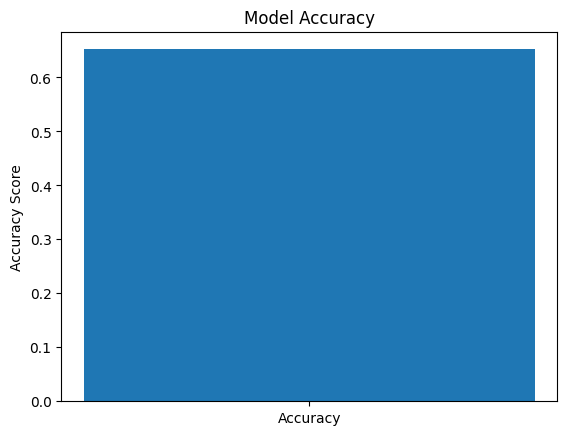

In [ ]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)

plt.bar(['Accuracy'], [accuracy])
plt.title('Model Accuracy')
plt.ylabel('Accuracy Score')
plt.show()

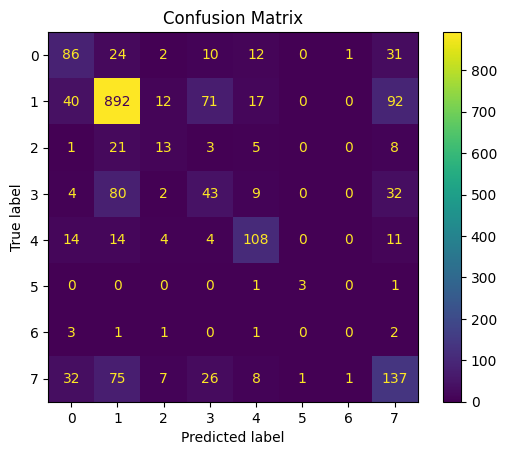

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
X = df[['year', 'vote', 'runtime', 'content_age']]
y = df['kind']

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5783316378433367


In [ ]:
X = df[['year', 'vote', 'runtime', 'content_age']]
y = df['rating']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print("R2 Score:", score)

R2 Score: 0.044296097884720775
